# Heat gains and flexibility in a district-cooling network

A district-cooling network is **colder than everything around it**. Buried mains
gain heat from the soil, an ice tank gains heat from the air, and both gains are
a load the plant has to remove again. Until you account for them:

* the plant duty looks equal to the sum of the building loads (it is not);
* the distribution ΔT looks like the design ΔT (it is not);
* and a thermal store looks like a free way to move energy in time (it is not).

This notebook works through all three, using
`configs/config_riyadh_heat_gains.yaml`: three buildings, 3 km of buried mains,
and a 2.4 MWh ice store, over a week of Riyadh July weather.

**What you will see**

1. Where the conductance numbers come from (geometry → UA), before any solving
2. The design point: plant duty > building demand, and the balance closing exactly
3. A week of operation with and without the store
4. A flexibility assessment that is honest about what the store costs

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

import discoolpy
from discoolpy import (
    assess_flexibility,
    build_system,
    buried_pipe_UA_per_m,
    heat_gain_summary,
    load_yaml_config,
    make_pipe_thermal,
    make_storage,
    make_weather_and_load_profiles,
    run_configured_case,
    soil_temperature_degC,
    tank_UA_W_K,
)

CONFIG = Path("../configs/config_riyadh_heat_gains.yaml")
config = load_yaml_config(CONFIG)
print(f"discoolpy {discoolpy.__version__}")
print(f"scenario : {config['metadata']['name']}")
print(f"buildings: {[b['label'] for b in config['buildings']]}")

discoolpy 1.0.0a1
scenario : config_riyadh_heat_gains
buildings: ['building 1', 'building 2', 'building 3']


## 1. Where the conductances come from

Nothing here needs a solver. A buried, insulated pipe has four resistances in
series: the internal water film, the steel wall, the insulation, and the soil,
and the per-metre conductance is their reciprocal:

$$
\frac{1}{U'} = \underbrace{\frac{1}{\pi D_i h_i}}_{\text{film}}
             + \underbrace{\frac{\ln(D_o/D_i)}{2\pi k_{\text{steel}}}}_{\text{wall}}
             + \underbrace{\frac{\ln(D_{\text{ins}}/D_o)}{2\pi k_{\text{ins}}}}_{\text{insulation}}
             + \underbrace{\frac{\operatorname{arccosh}(2z/D_{\text{ins}})}{2\pi k_{\text{soil}}}}_{\text{soil}}
$$

The insulation term dominates, which is why insulation thickness is the design
lever that actually matters.

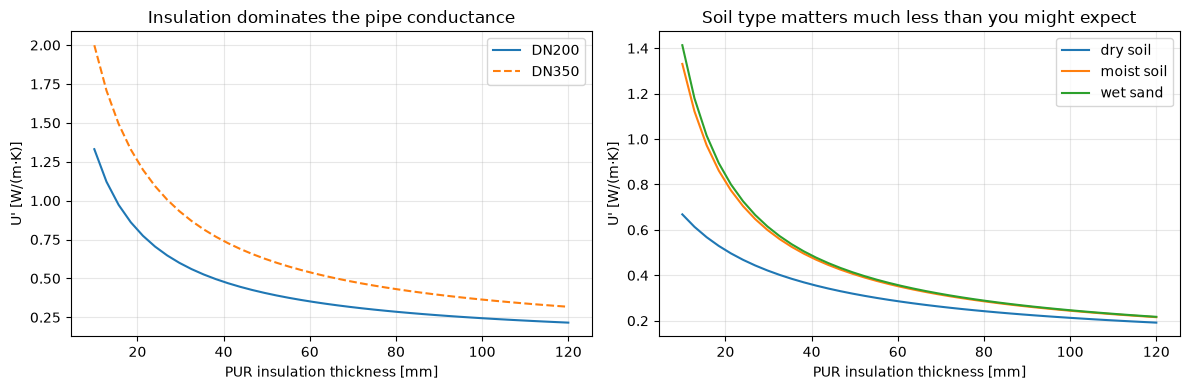

In [2]:
thickness = np.linspace(0.01, 0.12, 40)
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

for D, style in [(0.20, "-"), (0.35, "--")]:
    ua = [buried_pipe_UA_per_m(D, t, "pur", 1.2, "moist soil", pipe_wall_thickness_m=0.006)
          for t in thickness]
    ax[0].plot(thickness * 1000, ua, style, label=f"DN{int(D*1000)}")
ax[0].set_xlabel("PUR insulation thickness [mm]")
ax[0].set_ylabel("U' [W/(m·K)]")
ax[0].set_title("Insulation dominates the pipe conductance")
ax[0].legend(); ax[0].grid(alpha=0.3)

for ground in ["dry soil", "moist soil", "wet sand"]:
    ua = [buried_pipe_UA_per_m(0.20, t, "pur", 1.2, ground, pipe_wall_thickness_m=0.006)
          for t in thickness]
    ax[1].plot(thickness * 1000, ua, label=ground)
ax[1].set_xlabel("PUR insulation thickness [mm]")
ax[1].set_ylabel("U' [W/(m·K)]")
ax[1].set_title("Soil type matters much less than you might expect")
ax[1].legend(); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

In [3]:
# What the scenario file resolves to, pipe by pipe.
thermal = make_pipe_thermal(config)
rows = []
for key, spec in thermal.items():
    rows.append({
        "pipe": key,
        "L [m]": spec.length_m,
        "D [m]": spec.geometry.get("D"),
        "U' [W/(m·K)]": round(spec.UA_per_m_W_mK, 4),
        "UA [W/K]": round(spec.resolved_UA(), 1),
        "driven by": spec.ambient_source,
        "T_amb [°C]": spec.ambient_temperature_degC,
    })
pipes = pd.DataFrame(rows)
print(pipes.to_string(index=False))
print(f"\nTotal network conductance: {pipes['UA [W/K]'].sum():.0f} W/K")
print(f"At a 22 K drive that is {pipes['UA [W/K]'].sum() * 22 / 1000:.1f} kW of parasitic load.")

    pipe  L [m]  D [m]  U' [W/(m·K)]  UA [W/K] driven by  T_amb [°C]
supply_1  800.0  0.200        0.3894     311.5    ground        29.4
supply_2  400.0  0.150        0.3187     127.5    ground        29.4
supply_3  300.0  0.125        0.2823      84.7    ground        29.4
return_3  300.0  0.125        0.2823      84.7    ground        29.4
return_2  400.0  0.150        0.3187     127.5    ground        29.4
return_1  800.0  0.200        0.3894     311.5    ground        29.4

Total network conductance: 1047 W/K
At a 22 K drive that is 23.0 kW of parasitic load.


### Buried pipes see the soil, not the air

This distinction is easy to get wrong and it changes the answer. Soil at 1.2 m
lags the surface by about a month and swings by roughly 60 % of the surface
amplitude, so pipe heat gain is close to **constant over a day** even while air
temperature swings 15 K. A model that drives buried pipes with dry-bulb air
invents a daily cycle in pipe losses that does not exist.

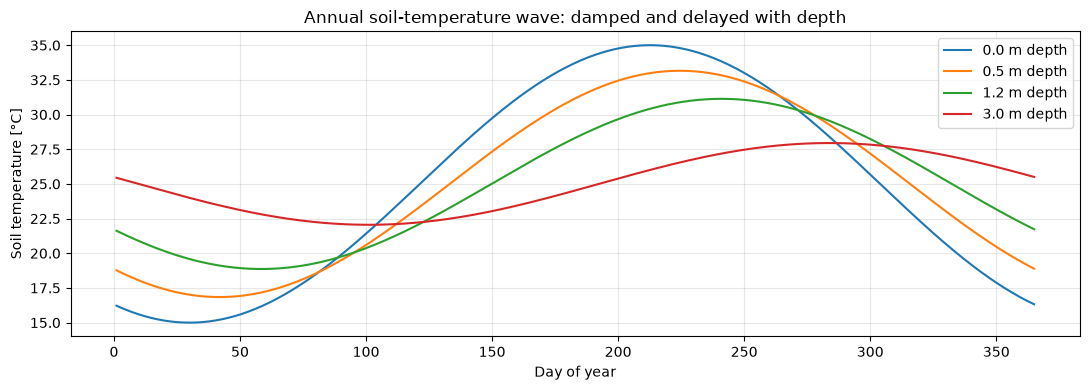

In [4]:
days = np.arange(1, 366)
fig, ax = plt.subplots(figsize=(11, 4))
for depth in [0.0, 0.5, 1.2, 3.0]:
    ax.plot(days, [soil_temperature_degC(d, 25.0, 10.0, depth) for d in days],
            label=f"{depth:.1f} m depth")
ax.set_xlabel("Day of year"); ax.set_ylabel("Soil temperature [°C]")
ax.set_title("Annual soil-temperature wave: damped and delayed with depth")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

In [5]:
# The ice tank, by contrast, sits in the air and is fully exposed to the swing.
storage = make_storage(config)
th = storage.thermal
print(f"Tank: {config['storage']['thermal']['volume_m3']} m³, "
      f"{config['storage']['thermal']['insulation_thickness_m']*1000:.0f} mm "
      f"{config['storage']['thermal']['insulation']}")
print(f"  UA = {th.UA_W_K:.1f} W/K, medium held at {th.storage_temperature_degC:.1f} °C\n")

legacy_kW = config['storage']['capacity_kWh'] * 0.015 / 24   # the old 1.5 %/day model
for T in [15, 25, 35, 45]:
    print(f"  ambient {T:2d} °C -> {th.heat_gain_W(T, 0.5)/1000:5.2f} kW "
          f"({th.heat_gain_W(T, 0.5)/1000/legacy_kW:4.1f}x the flat 1.5 %/day assumption)")
print(f"\nThe flat model would have predicted {legacy_kW:.2f} kW at every hour of the year.")

Tank: 420.0 m³, 100 mm pur
  UA = 82.2 W/K, medium held at 0.0 °C

  ambient 15 °C ->  1.23 kW ( 0.8x the flat 1.5 %/day assumption)
  ambient 25 °C ->  2.06 kW ( 1.4x the flat 1.5 %/day assumption)
  ambient 35 °C ->  2.88 kW ( 1.9x the flat 1.5 %/day assumption)
  ambient 45 °C ->  3.70 kW ( 2.5x the flat 1.5 %/day assumption)

The flat model would have predicted 1.50 kW at every hour of the year.


## 2. The design point

With heat gains active the plant duty can no longer be *asserted*: the loop
energy balance already determines it. DisCoolPy therefore releases the
evaporator duty and solves it, which is also the more faithful control model, 
a real plant modulates to hold a supply-temperature setpoint and reports its duty.

In [6]:
system = build_system(config)
for note in system.notes:
    print("note:", note)

system.network.solve(mode="design", max_iter=300)
assert system.network.converged

q_evap = system.chiller.solved_Q_evap_W
q_bldg = sum(b.component.Q.val for b in system.buildings)
gains = system.branch.heat_gain_report()
pump = system.branch.pump.P.val

print(f"\n  building cooling demand : {q_bldg/1e3:8.1f} kW")
print(f"  distribution pipe gain  : {gains['total_heat_gain_W']/1e3:8.1f} kW"
      f"   ({100*gains['total_heat_gain_W']/q_bldg:+.2f} %)")
print(f"  pump heat               : {pump/1e3:8.1f} kW")
print(f"  " + "-" * 34)
print(f"  plant duty (solved)     : {q_evap/1e3:8.1f} kW")
print(f"  balance residual        : {q_evap - q_bldg - gains['total_heat_gain_W'] - pump:8.4f} W")
print(f"\n  {system.branch.pressure_feasibility()['message']}")

note: Chiller duty is a solved output (plant_control='supply_temperature'); it equals building demand + pipe gains + pump heat + storage exchange - satellite plant duty.



  building cooling demand :    710.0 kW
  distribution pipe gain  :     20.7 kW   (+2.92 %)
  pump heat               :     12.8 kW
  ----------------------------------
  plant duty (solved)     :    743.5 kW
  balance residual        :   0.0000 W

  Branch pressure specification is feasible: every element drops pressure along the flow direction.


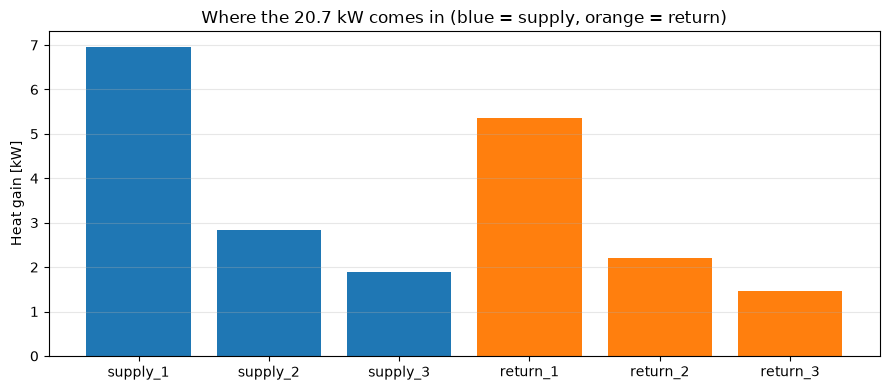

supply mains: 11.69 kW
return mains: 9.02 kW

Design ΔT was 5.00 K; the network actually runs at 5.20 K.


In [7]:
# Supply mains gain more than return mains: the water in them is colder, so the
# temperature difference driving heat through the insulation is larger.
per_pipe = pd.Series(gains["per_pipe_W"]) / 1000
fig, ax = plt.subplots(figsize=(9, 4))
colours = ["tab:blue" if k.startswith("supply") else "tab:orange" for k in per_pipe.index]
ax.bar(per_pipe.index, per_pipe.values, color=colours)
ax.set_ylabel("Heat gain [kW]")
ax.set_title(f"Where the {gains['total_heat_gain_W']/1e3:.1f} kW comes in "
             f"(blue = supply, orange = return)")
ax.grid(alpha=0.3, axis="y")
plt.tight_layout(); plt.show()

print(f"supply mains: {gains['supply_heat_gain_W']/1e3:.2f} kW")
print(f"return mains: {gains['return_heat_gain_W']/1e3:.2f} kW")
print(f"\nDesign ΔT was {config['design']['building_return_temperature_degC'] - config['design']['supply_temperature_degC']:.2f} K; "
      f"the network actually runs at "
      f"{system.branch.connections['branch_out'].T.val - system.branch.connections['branch_in'].T.val:.2f} K.")

## 3. A week of operation

Two runs over identical weather: one without the store, one with it. The store
is a real element in the chilled-water loop, so charging forces the plant to
produce water below the distribution setpoint, and pay for it.

In [8]:
profile = make_weather_and_load_profiles(config)
print(f"{len(profile)} snapshots at {config['profiles']['freq']}")
print(profile[["timestamp", "ambient_temperature_degC", "ground_temperature_degC",
               "solar_irradiance_W_m2", "total_building_Q_W"]].iloc[::24].to_string(index=False))

336 snapshots at 30min
          timestamp  ambient_temperature_degC  ground_temperature_degC  solar_irradiance_W_m2  total_building_Q_W
2026-07-01 00:00:00                 34.188267                28.232992                0.00000       405103.331144
2026-07-01 12:00:00                 37.811733                28.232992              943.07343       626933.948259
2026-07-02 00:00:00                 35.461908                28.322175                0.00000       425347.147560
2026-07-02 12:00:00                 39.085374                28.322175              943.07343       647177.764675
2026-07-03 00:00:00                 34.470078                28.410376                0.00000       407219.466251
2026-07-03 12:00:00                 37.912371                28.410376              943.07343       626362.246749
2026-07-04 00:00:00                 36.340126                28.497567                0.00000       436851.413724
2026-07-04 12:00:00                 39.963593                28.4

In [9]:
no_storage  = run_configured_case(config, profile, "nb_without_storage", use_storage=False, progress=False)
with_storage = run_configured_case(config, profile, "nb_with_storage",  use_storage=True,  progress=False)
print(f"solved {len(no_storage)} + {len(with_storage)} snapshots")
print(f"max chilled-water energy residual: "
      f"{max(no_storage.chw_energy_residual_W.abs().max(), with_storage.chw_energy_residual_W.abs().max()):.2e} W")

Operating point below characteristic line range: X=0.487 with minimum of 0.55782 at component riyadh_heat_gain_chiller_compressor.


Operating point below characteristic line range: X=0.478 with minimum of 0.55782 at component riyadh_heat_gain_chiller_compressor.


Operating point below characteristic line range: X=0.47 with minimum of 0.55782 at component riyadh_heat_gain_chiller_compressor.


Operating point below characteristic line range: X=0.465 with minimum of 0.55782 at component riyadh_heat_gain_chiller_compressor.


Operating point below characteristic line range: X=0.463 with minimum of 0.55782 at component riyadh_heat_gain_chiller_compressor.


...

Operating point below characteristic line range: X=0.464 with minimum of 0.55782 at component riyadh_heat_gain_chiller_compressor.


Operating point below characteristic line range: X=0.461 with minimum of 0.55782 at component riyadh_heat_gain_chiller_compressor.


Operating point below characteristic line range: X=0.462 with minimum of 0.55782 at component riyadh_heat_gain_chiller_compressor.


Operating point below characteristic line range: X=0.466 with minimum of 0.55782 at component riyadh_heat_gain_chiller_compressor.


solved 336 + 336 snapshots
max chilled-water energy residual: 2.00e-08 W


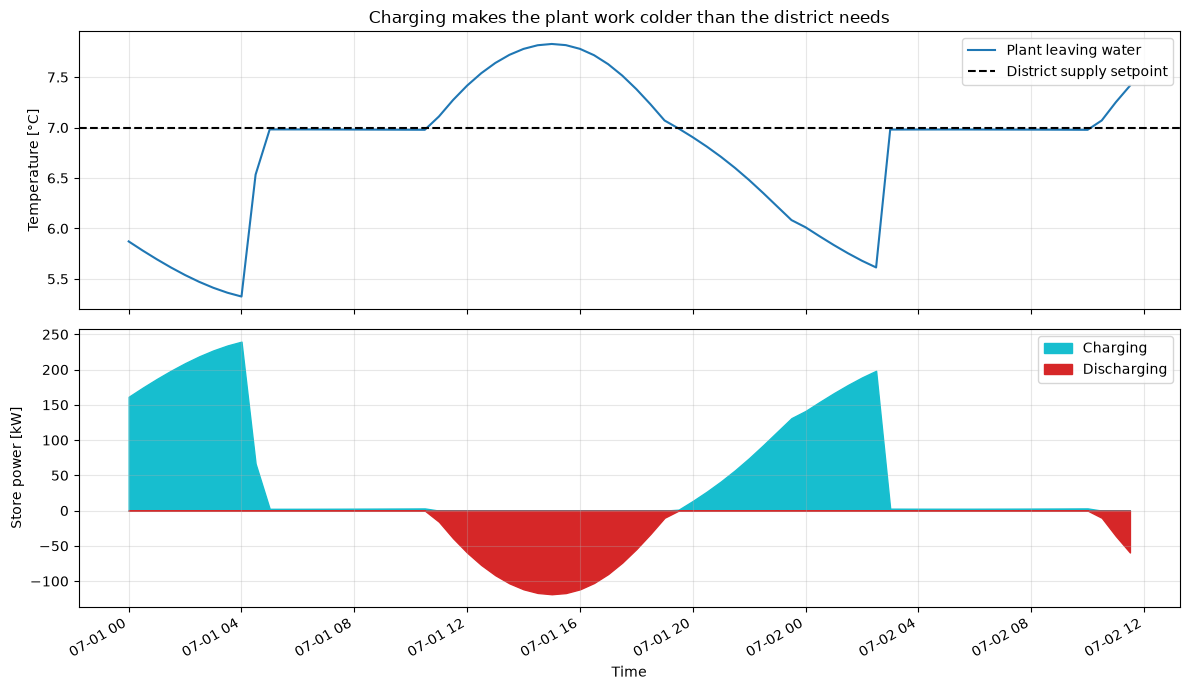

In [10]:
# The signature of a hydraulically coupled store: while charging, the plant's
# leaving water drops below the 7 °C the district receives.
ws = with_storage.copy()
ws["timestamp"] = pd.to_datetime(ws["timestamp"])
day = ws[ws.timestamp < ws.timestamp.iloc[0] + pd.Timedelta("36h")]

fig, ax = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
ax[0].plot(day.timestamp, day.chw_plant_supply_T_degC, color="tab:blue",
           label="Plant leaving water")
ax[0].axhline(config["design"]["supply_temperature_degC"], color="black", ls="--",
              label="District supply setpoint")
ax[0].set_ylabel("Temperature [°C]"); ax[0].legend(); ax[0].grid(alpha=0.3)
ax[0].set_title("Charging makes the plant work colder than the district needs")

ax[1].fill_between(day.timestamp, 0, day.storage_charge_power_W / 1e3,
                   color="tab:cyan", label="Charging")
ax[1].fill_between(day.timestamp, 0, -day.storage_discharge_power_W / 1e3,
                   color="tab:red", label="Discharging")
ax[1].set_ylabel("Store power [kW]"); ax[1].legend(); ax[1].grid(alpha=0.3)
ax[1].set_xlabel("Time")
fig.autofmt_xdate(); plt.tight_layout(); plt.show()

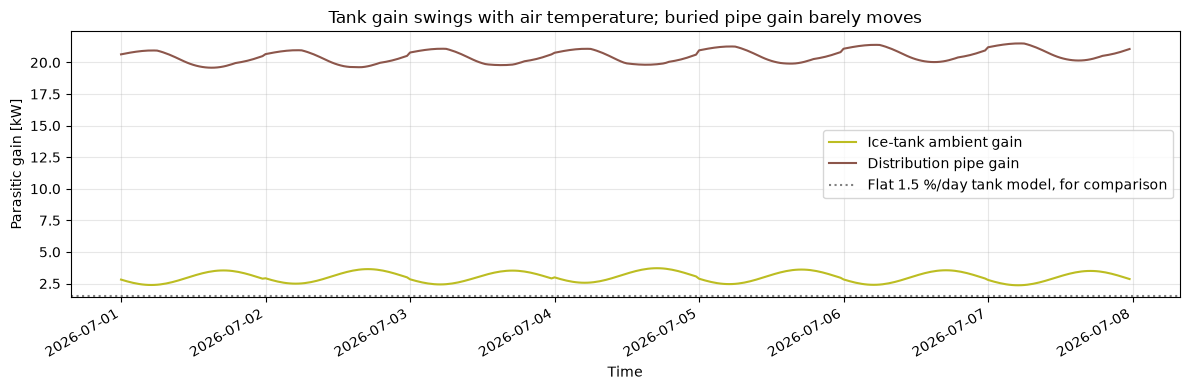

tank gain    : 2.36 to 3.71 kW
pipe gain    : 19.59 to 21.51 kW


In [11]:
# Storage heat gain tracks the weather, and peaks in the afternoon when the
# stored cooling is worth most. A flat %/day model cannot show this at all.
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(ws.timestamp, ws.storage_ambient_heat_gain_W / 1e3, color="tab:olive",
        label="Ice-tank ambient gain")
ax.plot(ws.timestamp, ws.pipe_heat_gain_W / 1e3, color="tab:brown",
        label="Distribution pipe gain")
ax.axhline(config["storage"]["capacity_kWh"] * 0.015 / 24, color="grey", ls=":",
           label="Flat 1.5 %/day tank model, for comparison")
ax.set_ylabel("Parasitic gain [kW]"); ax.set_xlabel("Time")
ax.set_title("Tank gain swings with air temperature; buried pipe gain barely moves")
ax.legend(); ax.grid(alpha=0.3)
fig.autofmt_xdate(); plt.tight_layout(); plt.show()

print(f"tank gain    : {ws.storage_ambient_heat_gain_W.min()/1e3:.2f} to "
      f"{ws.storage_ambient_heat_gain_W.max()/1e3:.2f} kW")
print(f"pipe gain    : {ws.pipe_heat_gain_W.min()/1e3:.2f} to "
      f"{ws.pipe_heat_gain_W.max()/1e3:.2f} kW")

## 4. What the store actually bought

The assessment separates four things that are easy to conflate:

| | |
|---|---|
| **Peak reduction** | what a demand charge pays for |
| **Energy penalty** | what the store costs in kWh |
| **Thermal round trip** | cooling out ÷ cooling in |
| **Electric round trip** | electricity avoided ÷ electricity spent, the one that decides whether it is worth running |

In [12]:
economics = config.get("economics", {})
report = assess_flexibility(
    no_storage, with_storage,
    reference_name="without storage", flexible_name="with ice storage",
    tariff=economics.get("tariff"),
    carbon_intensity=economics.get("carbon_intensity_kg_kWh"),
)
from IPython.display import Markdown, display
display(Markdown(report.to_markdown()))

# Flexibility assessment: `with ice storage` vs `without storage`

Horizon resolution: 0.5 h.

## Headline

| Metric | Reference | Flexible | Change |
|---|---:|---:|---:|
| Peak compressor power [kW] | 201.8 | 175.0 | -26.8 (-13.3%) |
| Compressor energy [kWh] | 26116.2 | 26360.5 | +244.3 (+0.9%) |
| Load factor [-] | 0.770 | 0.897 | +0.126 |
| Mean COP [-] | 3.460 | 3.505 | +0.045 |
| Max ramp up [kW/h] | 12.8 | 12.9 | +0.1 |

## Where the flexibility went

| Quantity | Value |
|---|---:|
| Cooling charged into store [kWh] | 6666.8 |
| Cooling discharged from store [kWh] | 5054.2 |
| Store losses (ambient gain + standby) [kWh] | 505.6 |
| Net change in stored cooling over the horizon [kWh] | +421.9 |
| Thermal round-trip efficiency [-] | 0.809 |
| **Electric** round-trip efficiency [-] | 0.853 |
| COP while charging, vs the same hour in the reference [-] | +0.066 |
| Energy shifted out of the peak [kWh] | 1220.0 |

## Economics

| Quantity | Reference | Flexible | Saving |
|---|---:|---:|---:|
| Electricity cost | 3731.82 | 3454.04 | +277.78 (+7.4%) |
| Emissions [kg CO2e] | 14363.9 | 14498.3 | -134.4 |

## Parasitic heat gains (reference)

| Source | Energy [kWh] | Share of building demand |
|---|---:|---:|
| Building demand served | 85607.2 | 100.0% |
| Distribution pipe gain | 3444.5 | 4.02% |
| Storage ambient gain | 0.0 | 0.00% |
| Pump heat | 2146.0 | 2.51% |
| **Plant cooling produced** | **91197.7** | 106.53% |

## Parasitic heat gains (flexible)

| Source | Energy [kWh] | Share of building demand |
|---|---:|---:|
| Building demand served | 85607.2 | 100.0% |
| Distribution pipe gain | 3444.5 | 4.02% |
| Storage ambient gain | 505.6 | 0.59% |
| Pump heat | 2146.0 | 2.51% |
| **Plant cooling produced** | **92810.3** | 108.41% |

## Notes

- This store buys 26.8 kW of peak reduction for 244.3 kWh of extra electricity. Whether that trade is worth making depends entirely on the tariff's demand charge.
- The store ended the horizon +421.9 kWh away from where it started. That energy is netted out of the round-trip figure, but a longer horizon or a cyclic-boundary run would give a cleaner comparison.

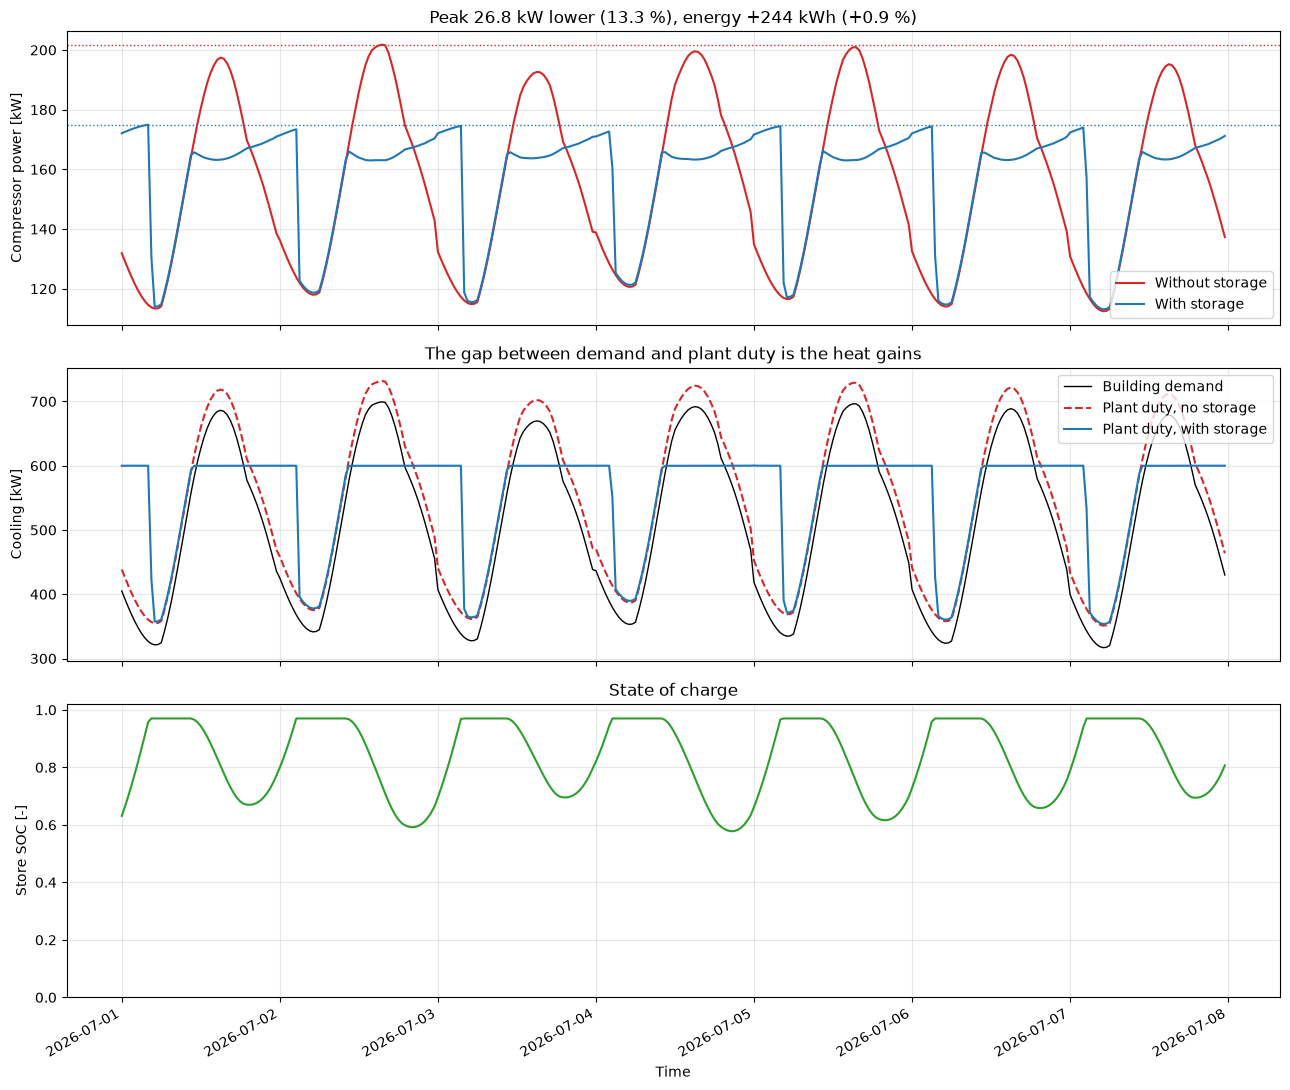

In [13]:
ns = no_storage.copy(); ns["timestamp"] = pd.to_datetime(ns["timestamp"])
fig, ax = plt.subplots(3, 1, figsize=(13, 11), sharex=True)

ax[0].plot(ns.timestamp, ns.compressor_power_W / 1e3, color="tab:red", label="Without storage")
ax[0].plot(ws.timestamp, ws.compressor_power_W / 1e3, color="tab:blue", label="With storage")
ax[0].axhline(ns.compressor_power_W.max() / 1e3, color="tab:red", ls=":", lw=1)
ax[0].axhline(ws.compressor_power_W.max() / 1e3, color="tab:blue", ls=":", lw=1)
ax[0].set_ylabel("Compressor power [kW]")
ax[0].set_title(f"Peak {report.peak_reduction_kW:.1f} kW lower "
                f"({report.peak_reduction_percent:.1f} %), energy "
                f"{report.energy_penalty_kWh:+.0f} kWh ({report.energy_penalty_percent:+.1f} %)")
ax[0].legend(); ax[0].grid(alpha=0.3)

ax[1].plot(ns.timestamp, ns.actual_building_total_Q_W / 1e3, color="black", lw=1,
           label="Building demand")
ax[1].plot(ns.timestamp, ns.chiller_Q_evap_W / 1e3, color="tab:red", ls="--",
           label="Plant duty, no storage")
ax[1].plot(ws.timestamp, ws.chiller_Q_evap_W / 1e3, color="tab:blue",
           label="Plant duty, with storage")
ax[1].set_ylabel("Cooling [kW]")
ax[1].set_title("The gap between demand and plant duty is the heat gains")
ax[1].legend(); ax[1].grid(alpha=0.3)

ax[2].plot(ws.timestamp, ws.storage_soc_after, color="tab:green")
ax[2].set_ylabel("Store SOC [-]"); ax[2].set_xlabel("Time"); ax[2].set_ylim(0, 1.02)
ax[2].set_title("State of charge"); ax[2].grid(alpha=0.3)
fig.autofmt_xdate(); plt.tight_layout(); plt.show()

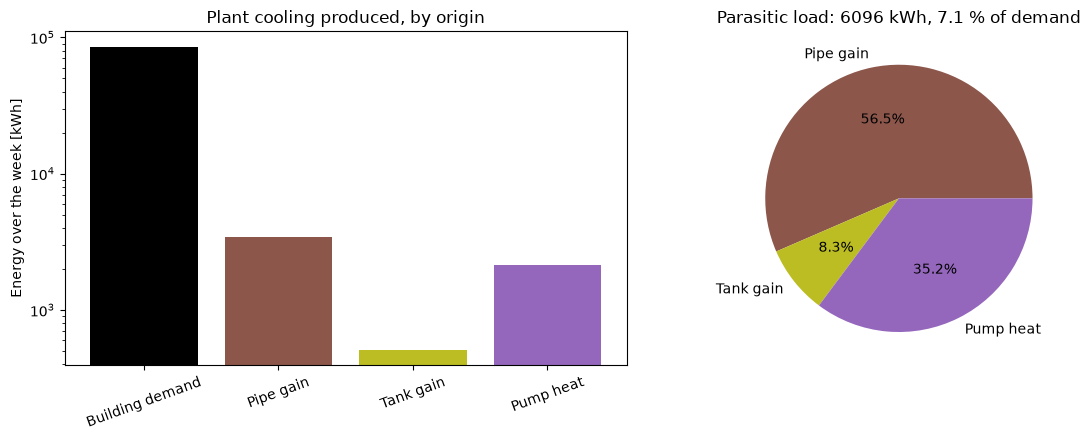

The plant produced 92810 kWh of cooling to deliver 85607 kWh to the buildings (108.4 %).


In [14]:
# Heat-gain accounting over the whole week.
summary = heat_gain_summary(with_storage)
labels = ["Building demand", "Pipe gain", "Tank gain", "Pump heat"]
values = [summary.building_demand_kWh, summary.pipe_gain_kWh,
          summary.storage_gain_kWh, summary.pump_heat_kWh]

fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
ax[0].bar(labels, values, color=["black", "tab:brown", "tab:olive", "tab:purple"])
ax[0].set_yscale("log"); ax[0].set_ylabel("Energy over the week [kWh]")
ax[0].set_title("Plant cooling produced, by origin"); ax[0].tick_params(axis="x", rotation=20)

parasitic = values[1:]
ax[1].pie(parasitic, labels=labels[1:], autopct="%1.1f%%",
          colors=["tab:brown", "tab:olive", "tab:purple"])
ax[1].set_title(f"Parasitic load: {sum(parasitic):.0f} kWh, "
                f"{100*sum(parasitic)/summary.building_demand_kWh:.1f} % of demand")
plt.tight_layout(); plt.show()

print(f"The plant produced {summary.plant_cooling_kWh:.0f} kWh of cooling to deliver "
      f"{summary.building_demand_kWh:.0f} kWh to the buildings "
      f"({100*summary.plant_cooling_kWh/summary.building_demand_kWh:.1f} %).")

## What to take away

1. **The plant produces several per cent more cooling than the buildings consume.**
   Sizing a plant against the sum of building peaks under-sizes it.
2. **Distribution gain is nearly constant; tank gain is not.** The tank's loss
   peaks in the afternoon, precisely when its stored cooling is most valuable,
   so a flat percentage-per-day model flatters storage in a hot climate.
3. **Thermal and electric round-trip efficiencies are different numbers.** The
   electric one accounts for the plant having to make colder water in order to
   charge, and it is the one that determines whether running the store pays.
4. **Peak and energy move in opposite directions.** This store cuts peak power
   and electricity cost while *increasing* both kWh and emissions. Whether that
   is a good trade depends entirely on the tariff, which is exactly the
   question a flexibility assessment should surface rather than hide.

Next: `precooling_flexibility.ipynb` does the same analysis for flexibility that
comes from the buildings rather than from a tank.